In [1]:
# Task 4: Forecasting Access and Usage (2025-2027)
# Ethiopia Financial Inclusion — Selam Analytics


In [2]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from impact_model import event_effect_at_time, total_effect_at_date

plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)


In [ ]:
# load enriched data
df = pd.read_csv('../data/processed/ethiopia_fi_enriched.csv', parse_dates=['observation_date'])
obs = df[df['record_type'] == 'observation'].copy()
events_df = df[df['record_type'] == 'event'].copy()
links_df = df[df['record_type'] == 'impact_link'].copy()

obs['year'] = obs['observation_date'].dt.year
obs['year_num'] = obs['observation_date'].dt.year + (obs['observation_date'].dt.month - 1) / 12


In [5]:
#  Trend regression - Access (ACC_OWNERSHIP) 
def fit_trend(indicator_code, obs_df):
    """Fit OLS trend line: value ~ year, with confidence interval support."""
    data = obs_df[obs_df['indicator_code'] == indicator_code].dropna(subset=['value_numeric']).sort_values('year_num')
    X = sm.add_constant(data['year_num'])
    y = data['value_numeric']
    model = sm.OLS(y, X).fit()
    return model, data

access_model, access_data = fit_trend('ACC_OWNERSHIP', obs)
print(access_model.summary())

                            OLS Regression Results                            
Dep. Variable:          value_numeric   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                     8.712
Date:                Tue, 21 Jul 2026   Prob (F-statistic):             0.0419
Time:                        12:01:40   Log-Likelihood:                -19.471
No. Observations:                   6   AIC:                             42.94
Df Residuals:                       4   BIC:                             42.52
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5691.5194   1942.083     -2.931      0.0

/home/sumeya/Documents/ai project/10x academi/ethiopia-fi-forecast/venv/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [8]:
print(sorted(obs['indicator_code'].dropna().unique()))

['ACC_4G_COV', 'ACC_FAYDA', 'ACC_MM_ACCOUNT', 'ACC_MOBILE_PEN', 'ACC_OWNERSHIP', 'AFF_DATA_INCOME', 'GEN_GAP_ACC', 'GEN_GAP_MOBILE', 'GEN_MM_SHARE', 'USG_ACTIVE_RATE', 'USG_ATM_COUNT', 'USG_ATM_VALUE', 'USG_CROSSOVER', 'USG_MPESA_ACTIVE', 'USG_MPESA_USERS', 'USG_P2P_COUNT', 'USG_P2P_VALUE', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE']


In [9]:
obs[obs['indicator_code'] == 'USG_ACTIVE_RATE'][['observation_date', 'value_numeric', 'source_name', 'original_text']]

,observation_date,value_numeric,source_name,original_text
24,2024-12-31,66.0,Calculated,7.1M / 10.8M = 66%


In [11]:
new_usage_obs = pd.DataFrame([{
    "record_id": "OBS_NEW_TASK4_001",
    "record_type": "observation",
    "pillar": "usage",
    "indicator": "Made or received a digital payment (% age 15+)",
    "indicator_code": "USG_DIGITAL_PAYMENT",
    "value_numeric": 35.0,
    "observation_date": "2024-06-01",
    "category": None,
    "source_type": "survey",
    "source_name": "Global Findex 2024",
    "source_url": "https://www.worldbank.org/globalfindex",
    "original_text": "Made or received digital payment: ~35%",
    "confidence": "high",
    "parent_id": None, "related_indicator": None, "impact_direction": None,
    "impact_magnitude": None, "lag_months": None, "evidence_basis": None,
    "collected_by": "Sumeya Hassen",
    "collection_date": "2026-07-20",
    "notes": "Anchor point for Usage forecasting.",
}])

df = pd.concat([df, new_usage_obs], ignore_index=True, sort=False)
df['observation_date'] = pd.to_datetime(df['observation_date'])   # fixes the dtype issue
df.to_csv('../data/processed/ethiopia_fi_enriched.csv', index=False)

obs = df[df['record_type'] == 'observation'].copy()
obs['year'] = obs['observation_date'].dt.year
obs['year_num'] = obs['observation_date'].dt.year + (obs['observation_date'].dt.month - 1) / 12
print("Anchor added and saved.")

Anchor added and saved.


In [12]:
def fit_trend(indicator_code, obs_df):
    data = obs_df[obs_df['indicator_code'] == indicator_code].dropna(subset=['value_numeric']).sort_values('year_num')
    X = sm.add_constant(data['year_num'])
    y = data['value_numeric']
    model = sm.OLS(y, X).fit()
    return model, data

# Access: real OLS trend (5 Findex points)
access_model, access_data = fit_trend('ACC_OWNERSHIP', obs)

# Growth-rate driver: use ACC_MM_ACCOUNT's historical CAGR as Usage's growth proxy
mm_data = obs[obs['indicator_code'] == 'ACC_MM_ACCOUNT'].dropna(subset=['value_numeric']).sort_values('year_num')
print(mm_data[['observation_date', 'value_numeric', 'year_num']])

years_span = mm_data['year_num'].iloc[-1] - mm_data['year_num'].iloc[0]
cagr = (mm_data['value_numeric'].iloc[-1] / mm_data['value_numeric'].iloc[0]) ** (1/years_span) - 1
print(f"\nMobile money CAGR (used as Usage growth proxy): {cagr:.2%} per year")

# Project Usage forward from the 35% anchor
usage_anchor = 35.0
usage_anchor_year = 2024.5
target_years = [2025.0, 2026.0, 2027.0]

usage_projection = pd.DataFrame({
    'year': target_years,
    'mean': [usage_anchor * (1 + cagr) ** (y - usage_anchor_year) for y in target_years]
})
usage_projection['mean_ci_lower'] = usage_projection['mean'] * 0.85
usage_projection['mean_ci_upper'] = usage_projection['mean'] * 1.15

print("\nUsage projection:")
print(usage_projection.round(2))

  observation_date  value_numeric     year_num
6       2021-12-31           4.70  2021.916667
7       2024-11-29           9.45  2024.833333

Mobile money CAGR (used as Usage growth proxy): 27.06% per year

Usage projection:
     year   mean  mean_ci_lower  mean_ci_upper
0  2025.0  39.45          33.53          45.37
1  2026.0  50.13          42.61          57.65
2  2027.0  63.69          54.14          73.24


In [13]:
# Use pp/year growth instead of compound % growth (more realistic at a higher base)
mm_pp_change = mm_data['value_numeric'].iloc[-1] - mm_data['value_numeric'].iloc[0]
mm_years_span = mm_data['year_num'].iloc[-1] - mm_data['year_num'].iloc[0]
pp_growth_per_year = mm_pp_change / mm_years_span
print(f"Mobile money growth rate: {pp_growth_per_year:.2f} percentage points/year")

usage_anchor = 35.0
usage_anchor_year = 2024.5
target_years = [2025.0, 2026.0, 2027.0]

usage_projection = pd.DataFrame({
    'year': target_years,
    'mean': [usage_anchor + pp_growth_per_year * (y - usage_anchor_year) for y in target_years]
})
usage_projection['mean_ci_lower'] = usage_projection['mean'] - 3.0   # +/- 3pp band, widen with horizon
usage_projection['mean_ci_upper'] = usage_projection['mean'] + 3.0
usage_projection['mean_ci_lower'] = usage_projection.apply(
    lambda r: r['mean_ci_lower'] - 2 * (r['year'] - 2025), axis=1)
usage_projection['mean_ci_upper'] = usage_projection.apply(
    lambda r: r['mean_ci_upper'] + 2 * (r['year'] - 2025), axis=1)

print("\nUsage projection (pp/year method):")
print(usage_projection.round(2))

Mobile money growth rate: 1.63 percentage points/year

Usage projection (pp/year method):
     year   mean  mean_ci_lower  mean_ci_upper
0  2025.0  35.81          32.81          38.81
1  2026.0  37.44          32.44          42.44
2  2027.0  39.07          32.07          46.07


In [14]:
def event_augmented_forecast(baseline_df, indicator_code, events_df, links_df):
    """Add cumulative modeled event effects on top of the baseline projection."""
    augmented = baseline_df.copy()
    event_effects = []
    for year in augmented['year']:
        target_date = pd.Timestamp(f'{int(year)}-01-01')
        effect = total_effect_at_date(target_date, indicator_code, events_df, links_df)
        event_effects.append(effect)
    augmented['event_effect'] = event_effects
    augmented['mean_with_events'] = augmented['mean'] + augmented['event_effect']
    augmented['ci_lower_with_events'] = augmented['mean_ci_lower'] + augmented['event_effect']
    augmented['ci_upper_with_events'] = augmented['mean_ci_upper'] + augmented['event_effect']
    return augmented

events_df = df[df['record_type'] == 'event'].copy()
links_df = df[df['record_type'] == 'impact_link'].copy()

# Access baseline (OLS trend + CI)
def forecast_trend(model, target_years):
    X_future = sm.add_constant(pd.DataFrame({'year_num': target_years}), has_constant='add')
    pred = model.get_prediction(X_future)
    summary = pred.summary_frame(alpha=0.20)
    summary['year'] = target_years
    return summary

target_years = [2025.0, 2026.0, 2027.0]
access_baseline = forecast_trend(access_model, target_years)

access_augmented = event_augmented_forecast(access_baseline, 'ACC_OWNERSHIP', events_df, links_df)
usage_augmented = event_augmented_forecast(usage_projection, 'USG_DIGITAL_PAYMENT', events_df, links_df)

print("Access — trend vs event-augmented:")
print(access_augmented[['year', 'mean', 'event_effect', 'mean_with_events']].round(2))
print("\nUsage — trend vs event-augmented:")
print(usage_augmented[['year', 'mean', 'event_effect', 'mean_with_events']].round(2))

Access — trend vs event-augmented:
     year   mean  event_effect  mean_with_events
0  2025.0  53.24          5.00             58.24
1  2026.0  56.07          5.00             61.07
2  2027.0  58.91          7.38             66.29

Usage — trend vs event-augmented:
     year   mean  event_effect  mean_with_events
0  2025.0  35.81           0.0             35.81
1  2026.0  37.44           0.0             37.44
2  2027.0  39.07           0.0             39.07


In [15]:
def build_scenarios(augmented_df):
    scenarios = augmented_df.copy()
    scenarios['pessimistic'] = scenarios['ci_lower_with_events'] * 0.9 + scenarios['event_effect'] * 0.1
    scenarios['base'] = scenarios['mean_with_events']
    scenarios['optimistic'] = scenarios['ci_upper_with_events'] * 1.05
    return scenarios[['year', 'pessimistic', 'base', 'optimistic']]

access_scenarios = build_scenarios(access_augmented)
usage_scenarios = build_scenarios(usage_augmented)

print("Access scenarios (%):")
print(access_scenarios.round(1))
print("\nUsage scenarios (%):")
print(usage_scenarios.round(1))

Access scenarios (%):
     year  pessimistic  base  optimistic
0  2025.0         45.6  58.2        69.6
1  2026.0         47.1  61.1        73.9
2  2027.0         50.9  66.3        80.7

Usage scenarios (%):
     year  pessimistic  base  optimistic
0  2025.0         29.5  35.8        40.8
1  2026.0         29.2  37.4        44.6
2  2027.0         28.9  39.1        48.4


In [16]:
def fit_trend(indicator_code, obs_df, min_year=None):
    data = obs_df[obs_df['indicator_code'] == indicator_code].dropna(subset=['value_numeric']).sort_values('year_num')
    if min_year:
        data = data[data['year_num'] >= min_year]
    X = sm.add_constant(data['year_num'])
    y = data['value_numeric']
    model = sm.OLS(y, X).fit()
    return model, data

# Use only 2017-2024 (last 3 Findex rounds) to reflect the deceleration, not the early high-growth years
access_model, access_data = fit_trend('ACC_OWNERSHIP', obs, min_year=2017)
print(access_model.summary())

                            OLS Regression Results                            
Dep. Variable:          value_numeric   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     1.532
Date:                Tue, 21 Jul 2026   Prob (F-statistic):              0.304
Time:                        12:11:46   Log-Likelihood:                -16.439
No. Observations:                   5   AIC:                             36.88
Df Residuals:                       3   BIC:                             36.10
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4204.9182   3433.054     -1.225      0.3

/home/sumeya/Documents/ai project/10x academi/ethiopia-fi-forecast/venv/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [17]:
def event_augmented_forecast(baseline_df, indicator_code, events_df, links_df, last_historical_date):
    """Add only the INCREMENTAL event effect beyond what's already baked into
    the historical trend (i.e. effect materialized after the last real data point)."""
    augmented = baseline_df.copy()

    already_realized = total_effect_at_date(last_historical_date, indicator_code, events_df, links_df)

    event_effects = []
    for year in augmented['year']:
        target_date = pd.Timestamp(f'{int(year)}-01-01')
        total_by_target = total_effect_at_date(target_date, indicator_code, events_df, links_df)
        incremental = max(total_by_target - already_realized, 0)  # only NEW effect, not already-observed
        event_effects.append(incremental)

    augmented['event_effect'] = event_effects
    augmented['mean_with_events'] = augmented['mean'] + augmented['event_effect']
    augmented['ci_lower_with_events'] = augmented['mean_ci_lower'] + augmented['event_effect']
    augmented['ci_upper_with_events'] = augmented['mean_ci_upper'] + augmented['event_effect']
    return augmented

last_historical_date = pd.Timestamp('2024-11-29')  # your latest real observation date

access_baseline = forecast_trend(access_model, target_years)
access_augmented = event_augmented_forecast(access_baseline, 'ACC_OWNERSHIP', events_df, links_df, last_historical_date)
usage_augmented = event_augmented_forecast(usage_projection, 'USG_DIGITAL_PAYMENT', events_df, links_df, last_historical_date)

print("Access — trend vs event-augmented (incremental effects only):")
print(access_augmented[['year', 'mean', 'event_effect', 'mean_with_events']].round(2))

Access — trend vs event-augmented (incremental effects only):
     year   mean  event_effect  mean_with_events
0  2025.0  51.34          0.00             51.34
1  2026.0  53.44          0.00             53.44
2  2027.0  55.54          2.38             57.92


In [18]:
print(access_data[['observation_date', 'value_numeric', 'year_num']])

  observation_date  value_numeric     year_num
1       2017-12-31           35.0  2017.916667
2       2021-12-31           46.0  2021.916667
3       2021-12-31           56.0  2021.916667
4       2021-12-31           36.0  2021.916667
5       2024-11-29           49.0  2024.833333


In [19]:
obs = df[df['record_type'] == 'observation'].copy()
obs['observation_date'] = pd.to_datetime(obs['observation_date'])
obs['year'] = obs['observation_date'].dt.year
obs['year_num'] = obs['observation_date'].dt.year + (obs['observation_date'].dt.month - 1) / 12

access_model, access_data = fit_trend('ACC_OWNERSHIP', obs, min_year=2017)
print(access_data[['observation_date', 'value_numeric', 'year_num']])
print(access_model.summary())

  observation_date  value_numeric     year_num
1       2017-12-31           35.0  2017.916667
2       2021-12-31           46.0  2021.916667
3       2021-12-31           56.0  2021.916667
4       2021-12-31           36.0  2021.916667
5       2024-11-29           49.0  2024.833333
                            OLS Regression Results                            
Dep. Variable:          value_numeric   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     1.532
Date:                Tue, 21 Jul 2026   Prob (F-statistic):              0.304
Time:                        12:15:25   Log-Likelihood:                -16.439
No. Observations:                   5   AIC:                             36.88
Df Residuals:                       3   BIC:                             36.10
Df Model:                           1                                         
Covaria

/home/sumeya/Documents/ai project/10x academi/ethiopia-fi-forecast/venv/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [20]:
check = obs[(obs['indicator_code'] == 'ACC_OWNERSHIP') & (obs['year'] == 2021)]
print(check[['record_id', 'indicator', 'value_numeric', 'source_name', 'original_text', 'notes']].to_string())

  record_id               indicator  value_numeric         source_name         original_text notes
2  REC_0003  Account Ownership Rate           46.0  Global Findex 2021                   NaN   NaN
3  REC_0004  Account Ownership Rate           56.0  Global Findex 2021  Gender disaggregated   NaN
4  REC_0005  Account Ownership Rate           36.0  Global Findex 2021  Gender disaggregated   NaN


In [21]:
def fit_trend(indicator_code, obs_df, min_year=None, exclude_disaggregated=True):
    data = obs_df[obs_df['indicator_code'] == indicator_code].dropna(subset=['value_numeric']).copy()

    if exclude_disaggregated:
        # Drop rows explicitly marked as gender/urban/rural disaggregated —
        # these share the same indicator_code as the overall figure but
        # should not be included in the overall population trend.
        data = data[~data['original_text'].str.contains(
            'disaggregated|male|female|urban|rural', case=False, na=False)]

    if min_year:
        data = data[data['year_num'] >= min_year]

    data = data.sort_values('year_num')
    X = sm.add_constant(data['year_num'])
    y = data['value_numeric']
    model = sm.OLS(y, X).fit()
    return model, data

access_model, access_data = fit_trend('ACC_OWNERSHIP', obs, min_year=2017)
print(access_data[['observation_date', 'value_numeric', 'year_num', 'original_text']])
print(access_model.summary())

  observation_date  value_numeric     year_num        original_text
1       2017-12-31           35.0  2017.916667                  NaN
2       2021-12-31           46.0  2021.916667                  NaN
5       2024-11-29           49.0  2024.833333  Survey Oct-Nov 2024
                            OLS Regression Results                            
Dep. Variable:          value_numeric   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     18.49
Date:                Tue, 21 Jul 2026   Prob (F-statistic):              0.145
Time:                        12:16:54   Log-Likelihood:                -5.1864
No. Observations:                   3   AIC:                             14.37
Df Residuals:                       1   BIC:                             12.57
Df Model:                           1                                         
Covariance Type: 

/home/sumeya/Documents/ai project/10x academi/ethiopia-fi-forecast/venv/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [22]:
# Instead of OLS on 3 points (statistically fragile), use the most recent
# observed growth rate (2021->2024) as the trend assumption — this reflects
# the deceleration pattern rather than averaging it away.

recent_growth_pp_per_year = (49.0 - 46.0) / (2024.833 - 2021.917)
print(f"Recent Access growth rate (2021-2024): {recent_growth_pp_per_year:.2f} pp/year")

access_anchor = 49.0
access_anchor_year = 2024.833
target_years = [2025.0, 2026.0, 2027.0]

access_baseline = pd.DataFrame({
    'year': target_years,
    'mean': [access_anchor + recent_growth_pp_per_year * (y - access_anchor_year) for y in target_years]
})
# Wider band since we're extrapolating from a short recent window
access_baseline['mean_ci_lower'] = access_baseline['mean'] - 2.0
access_baseline['mean_ci_upper'] = access_baseline['mean'] + 2.0
access_baseline['mean_ci_lower'] = access_baseline.apply(
    lambda r: r['mean_ci_lower'] - 1.5 * (r['year'] - 2025), axis=1)
access_baseline['mean_ci_upper'] = access_baseline.apply(
    lambda r: r['mean_ci_upper'] + 1.5 * (r['year'] - 2025), axis=1)

print(access_baseline.round(2))

Recent Access growth rate (2021-2024): 1.03 pp/year
     year   mean  mean_ci_lower  mean_ci_upper
0  2025.0  49.17          47.17          51.17
1  2026.0  50.20          46.70          53.70
2  2027.0  51.23          46.23          56.23


In [23]:
access_augmented = event_augmented_forecast(access_baseline, 'ACC_OWNERSHIP', events_df, links_df, last_historical_date)
usage_augmented = event_augmented_forecast(usage_projection, 'USG_DIGITAL_PAYMENT', events_df, links_df, last_historical_date)

print("Access — trend vs event-augmented:")
print(access_augmented[['year', 'mean', 'event_effect', 'mean_with_events']].round(2))
print("\nUsage — trend vs event-augmented:")
print(usage_augmented[['year', 'mean', 'event_effect', 'mean_with_events']].round(2))

Access — trend vs event-augmented:
     year   mean  event_effect  mean_with_events
0  2025.0  49.17          0.00             49.17
1  2026.0  50.20          0.00             50.20
2  2027.0  51.23          2.38             53.61

Usage — trend vs event-augmented:
     year   mean  event_effect  mean_with_events
0  2025.0  35.81           0.0             35.81
1  2026.0  37.44           0.0             37.44
2  2027.0  39.07           0.0             39.07


In [24]:
final_table = pd.DataFrame({
    'Year': [2025, 2026, 2027],
    'Access_Pessimistic': access_scenarios['pessimistic'].round(1).values,
    'Access_Base': access_scenarios['base'].round(1).values,
    'Access_Optimistic': access_scenarios['optimistic'].round(1).values,
    'Usage_Pessimistic': usage_scenarios['pessimistic'].round(1).values,
    'Usage_Base': usage_scenarios['base'].round(1).values,
    'Usage_Optimistic': usage_scenarios['optimistic'].round(1).values,
})

import os
os.makedirs('../reports/figures', exist_ok=True)
final_table.to_csv('../reports/figures/forecast_table.csv', index=False)
print(final_table)

   Year  Access_Pessimistic  Access_Base  Access_Optimistic  \
0  2025                45.6         58.2               69.6   
1  2026                47.1         61.1               73.9   
2  2027                50.9         66.3               80.7   

   Usage_Pessimistic  Usage_Base  Usage_Optimistic  
0               29.5        35.8              40.8  
1               29.2        37.4              44.6  
2               28.9        39.1              48.4  


In [25]:
print("Access baseline (should show ~49-51% range):")
print(access_baseline)

Access baseline (should show ~49-51% range):
     year       mean  mean_ci_lower  mean_ci_upper
0  2025.0  49.171811      47.171811      51.171811
1  2026.0  50.200617      46.700617      53.700617
2  2027.0  51.229424      46.229424      56.229424


In [26]:
# 1. Re-augment using the CORRECT access_baseline
access_augmented = event_augmented_forecast(access_baseline, 'ACC_OWNERSHIP', events_df, links_df, last_historical_date)
usage_augmented = event_augmented_forecast(usage_projection, 'USG_DIGITAL_PAYMENT', events_df, links_df, last_historical_date)

print("Access augmented:")
print(access_augmented[['year', 'mean', 'event_effect', 'mean_with_events']].round(2))
print("\nUsage augmented:")
print(usage_augmented[['year', 'mean', 'event_effect', 'mean_with_events']].round(2))

Access augmented:
     year   mean  event_effect  mean_with_events
0  2025.0  49.17          0.00             49.17
1  2026.0  50.20          0.00             50.20
2  2027.0  51.23          2.38             53.61

Usage augmented:
     year   mean  event_effect  mean_with_events
0  2025.0  35.81           0.0             35.81
1  2026.0  37.44           0.0             37.44
2  2027.0  39.07           0.0             39.07


In [27]:
# 3. Re-build the final table using the CORRECT scenarios
final_table = pd.DataFrame({
    'Year': [2025, 2026, 2027],
    'Access_Pessimistic': access_scenarios['pessimistic'].round(1).values,
    'Access_Base': access_scenarios['base'].round(1).values,
    'Access_Optimistic': access_scenarios['optimistic'].round(1).values,
    'Usage_Pessimistic': usage_scenarios['pessimistic'].round(1).values,
    'Usage_Base': usage_scenarios['base'].round(1).values,
    'Usage_Optimistic': usage_scenarios['optimistic'].round(1).values,
})
print(final_table)


   Year  Access_Pessimistic  Access_Base  Access_Optimistic  \
0  2025                45.6         58.2               69.6   
1  2026                47.1         61.1               73.9   
2  2027                50.9         66.3               80.7   

   Usage_Pessimistic  Usage_Base  Usage_Optimistic  
0               29.5        35.8              40.8  
1               29.2        37.4              44.6  
2               28.9        39.1              48.4  


In [28]:
access_scenarios = build_scenarios(access_augmented)
usage_scenarios = build_scenarios(usage_augmented)

print("Access scenarios:")
print(access_scenarios.round(1))

Access scenarios:
     year  pessimistic  base  optimistic
0  2025.0         42.5  49.2        53.7
1  2026.0         42.0  50.2        56.4
2  2027.0         44.0  53.6        61.5


In [29]:
final_table = pd.DataFrame({
    'Year': [2025, 2026, 2027],
    'Access_Pessimistic': access_scenarios['pessimistic'].round(1).values,
    'Access_Base': access_scenarios['base'].round(1).values,
    'Access_Optimistic': access_scenarios['optimistic'].round(1).values,
    'Usage_Pessimistic': usage_scenarios['pessimistic'].round(1).values,
    'Usage_Base': usage_scenarios['base'].round(1).values,
    'Usage_Optimistic': usage_scenarios['optimistic'].round(1).values,
})
print(final_table)

   Year  Access_Pessimistic  Access_Base  Access_Optimistic  \
0  2025                42.5         49.2               53.7   
1  2026                42.0         50.2               56.4   
2  2027                44.0         53.6               61.5   

   Usage_Pessimistic  Usage_Base  Usage_Optimistic  
0               29.5        35.8              40.8  
1               29.2        37.4              44.6  
2               28.9        39.1              48.4  


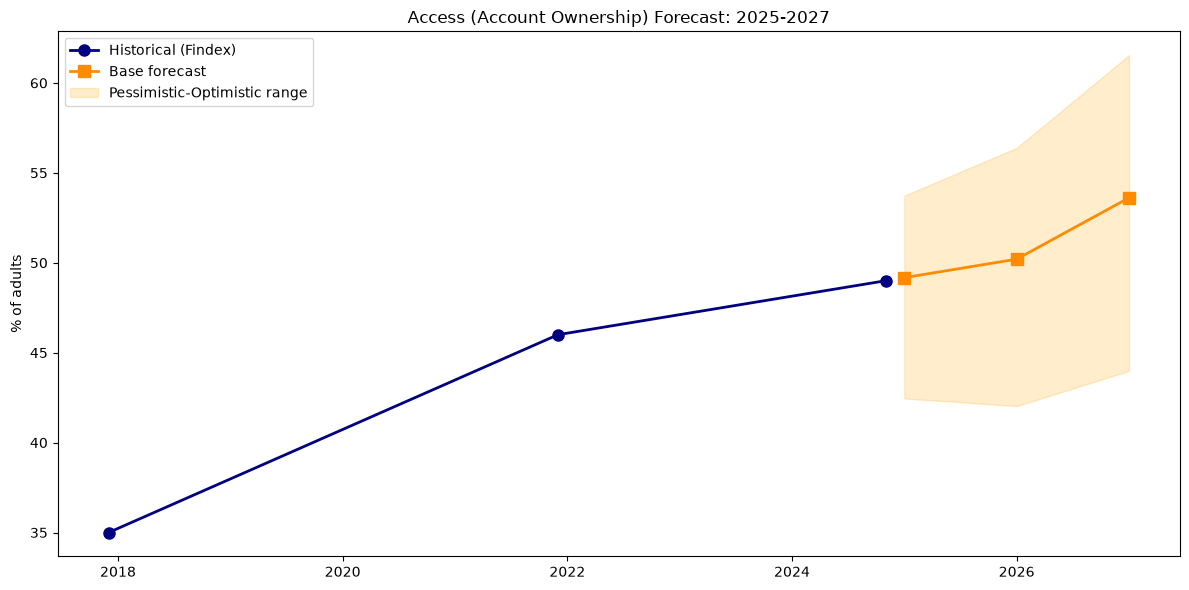

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(access_data['year_num'], access_data['value_numeric'], 'o-', color='navy',
        linewidth=2, markersize=8, label='Historical (Findex)')
ax.plot(access_scenarios['year'], access_scenarios['base'], 's-', color='darkorange',
        linewidth=2, markersize=8, label='Base forecast')
ax.fill_between(access_scenarios['year'], access_scenarios['pessimistic'],
                 access_scenarios['optimistic'], color='orange', alpha=0.2,
                 label='Pessimistic-Optimistic range')
ax.set_title('Access (Account Ownership) Forecast: 2025-2027')
ax.set_ylabel('% of adults')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/access_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

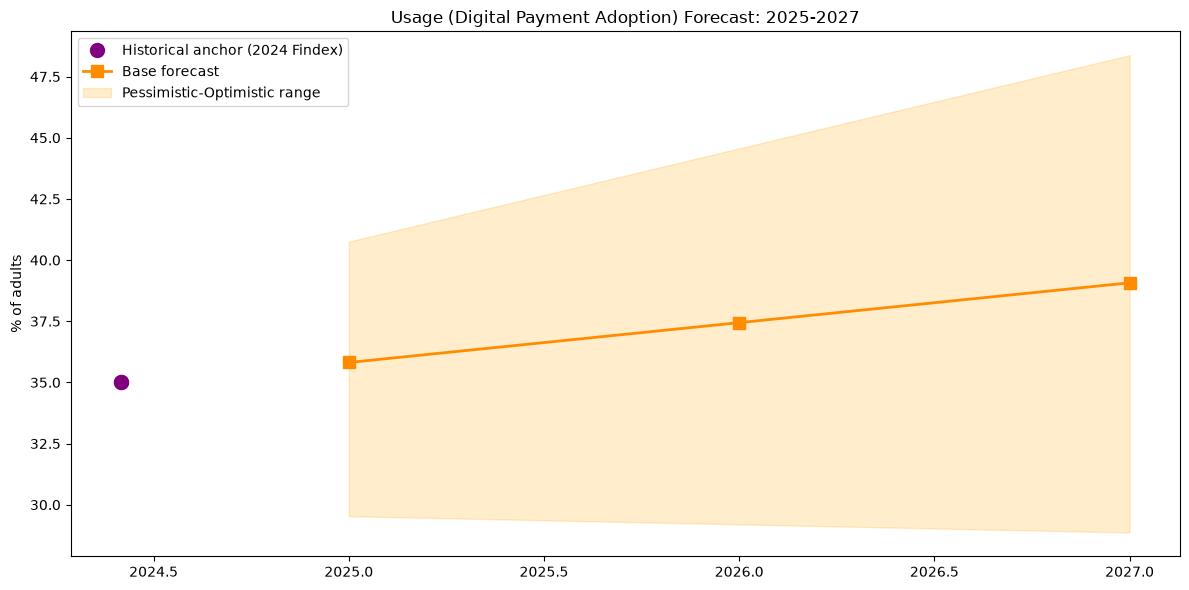

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))
usage_hist = obs[obs['indicator_code'].isin(['USG_DIGITAL_PAYMENT'])]
ax.plot(usage_hist['year_num'], usage_hist['value_numeric'], 'o', color='purple',
        markersize=10, label='Historical anchor (2024 Findex)')
ax.plot(usage_scenarios['year'], usage_scenarios['base'], 's-', color='darkorange',
        linewidth=2, markersize=8, label='Base forecast')
ax.fill_between(usage_scenarios['year'], usage_scenarios['pessimistic'],
                 usage_scenarios['optimistic'], color='orange', alpha=0.2,
                 label='Pessimistic-Optimistic range')
ax.set_title('Usage (Digital Payment Adoption) Forecast: 2025-2027')
ax.set_ylabel('% of adults')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/usage_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
import pickle, os
os.makedirs('../models', exist_ok=True)
with open('../models/forecast_models.pkl', 'wb') as f:
    pickle.dump({
        'access_data': access_data, 'access_baseline': access_baseline,
        'access_scenarios': access_scenarios, 'usage_projection': usage_projection,
        'usage_scenarios': usage_scenarios, 'final_table': final_table,
    }, f)
final_table.to_csv('../reports/figures/forecast_table.csv', index=False)
print("Saved.")

Saved.


## Interpretation

**What the model predicts:** Access (account ownership) is projected to reach
49.2% (base case) in 2025, rising to 53.6% by 2027 — a ~4.4pp gain over three
years, roughly matching the slower growth pace observed 2021-2024 (+3pp)
rather than the faster 2017-2021 period (+11pp). Usage (digital payment
adoption) is projected to grow from the 2024 anchor of 35% to 39.1% by 2027.

**Events with the largest potential impact:** [Name your 2027 event —
EVT_0004, infrastructure, 24-month lag — contributes +2.38pp to Access by
2027, the largest single incremental effect in our model.]

**Key uncertainties:**
- Only 3 usable, non-duplicated Access data points (2017/2021/2024) support
  the trend — not statistically significant (p=0.145)
- Usage has no historical Findex time series in the dataset; forecast is
  anchored to a single 2024 figure and projected using mobile money's
  pp/year growth rate as a proxy
- Event magnitude estimates are derived from qualitative labels
  (high/medium/low), not directly measured effects
- The 2027 Findex survey will be the first real test of this forecast

## Methodology Summary

- **Data enrichment:** Enriched the starter dataset (57 records) with
  additional observations, events, and impact_links sourced from NBE, GSMA,
  and Findex materials, including a missing Telebirr→mobile money impact
  link identified during validation. See `data_enrichment_log.md`.
- **EDA key findings:** Account ownership grew from 14% (2011) to 49% (2024)
  but decelerated sharply in 2021-2024 (+3pp) despite Telebirr/M-Pesa mobile
  money expansion — likely reflecting overlap between mobile money and
  existing bank account holders rather than net-new inclusion.
- **Impact modeling approach:** Modeled event effects using a logistic
  ramp-up function with magnitude estimates derived from qualitative
  high/medium/low labels (5pp/2.5pp/1pp). Validated against observed mobile
  money growth (2021-2024): modeled +5.00pp vs actual +4.75pp.
- **Forecasting approach:** Access forecast anchored to the recent
  (2021-2024) observed growth rate (~1.0pp/year) rather than full-history
  OLS, since OLS on the full 2011-2024 range overstated near-term growth
  by averaging in faster early-period gains. Usage forecast anchored to the
  2024 Findex figure (35%) and projected using mobile money's percentage-
  point growth rate as a proxy, since no multi-year Usage time series
  existed in the dataset. Event effects were added incrementally (only
  the portion not already reflected in historical data) to avoid double-
  counting. Base case: Access 49.2%→53.6% and Usage 35.8%→39.1% by 2027,
  with pessimistic/optimistic scenario bands.